<a href="https://colab.research.google.com/github/mfernandezzz/Pruebas_Tecnicas/blob/main/TT_data_music.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv('/content/data_music.csv')
pd.set_option('display.max_columns', None)

In [ ]:
df.shape

(953, 25)

In [ ]:
df.info(memory_usage='deep')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 953 entries, 0 to 952
Data columns (total 25 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   Unnamed: 0            953 non-null    int64 
 1   track_name            953 non-null    object
 2   artist(s)_name        953 non-null    object
 3   artist_count          953 non-null    int64 
 4   released_year         953 non-null    int64 
 5   released_month        953 non-null    int64 
 6   released_day          953 non-null    int64 
 7   in_spotify_playlists  953 non-null    int64 
 8   in_spotify_charts     953 non-null    int64 
 9   streams               953 non-null    int64 
 10  in_apple_playlists    953 non-null    int64 
 11  in_apple_charts       953 non-null    int64 
 12  in_deezer_playlists   953 non-null    object
 13  in_deezer_charts      953 non-null    int64 
 14  in_shazam_charts      903 non-null    object
 15  bpm                   953 non-null    in

In [ ]:
# for c in df.select_dtypes('object'):
#  df[c] = df[c].astype('object')

In [ ]:
for i in df.select_dtypes('integer'):
  df[i] = pd.to_numeric(df[i], downcast='integer')

In [ ]:
for f in df.select_dtypes('float'):
  df[f] = pd.to_numeric(df[f], downcast='float')

In [ ]:
df.info(memory_usage='deep')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 953 entries, 0 to 952
Data columns (total 25 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   Unnamed: 0            953 non-null    int16 
 1   track_name            953 non-null    object
 2   artist(s)_name        953 non-null    object
 3   artist_count          953 non-null    int8  
 4   released_year         953 non-null    int16 
 5   released_month        953 non-null    int8  
 6   released_day          953 non-null    int8  
 7   in_spotify_playlists  953 non-null    int32 
 8   in_spotify_charts     953 non-null    int16 
 9   streams               953 non-null    int64 
 10  in_apple_playlists    953 non-null    int16 
 11  in_apple_charts       953 non-null    int16 
 12  in_deezer_playlists   953 non-null    object
 13  in_deezer_charts      953 non-null    int8  
 14  in_shazam_charts      903 non-null    object
 15  bpm                   953 non-null    in

In [ ]:
df.columns = (
    df.columns
    .str.lower()
    .str.strip()
    .str.replace(' ', '_')
)
df.columns

Index(['unnamed:_0', 'track_name', 'artist(s)_name', 'artist_count',
       'released_year', 'released_month', 'released_day',
       'in_spotify_playlists', 'in_spotify_charts', 'streams',
       'in_apple_playlists', 'in_apple_charts', 'in_deezer_playlists',
       'in_deezer_charts', 'in_shazam_charts', 'bpm', 'key', 'mode',
       'danceability_%', 'valence_%', 'energy_%', 'acousticness_%',
       'instrumentalness_%', 'liveness_%', 'speechiness_%'],
      dtype='object')

In [ ]:
nulls_count = df.isnull().sum()
nulls_count[nulls_count > 0].sort_values(ascending=False)

,0
key,95
in_shazam_charts,50


In [ ]:
nulls_percentage = df.isnull().mean()*100
nulls_percentage[nulls_percentage > 0].sort_values(ascending=False)

,0
key,9.96852
in_shazam_charts,5.24659


In [ ]:
duplicates_sum = df.duplicated().sum()
duplicates_sum

np.int64(0)

In [ ]:
duplicates_percentage = (df.duplicated().sum()/df.shape[0]) * 100
duplicates_percentage

np.float64(0.0)

In [ ]:
# show_duplicates = df[df.duplicated(keep=False)].sort_values(by=list(df.columns)).head()
# show_duplicates

In [ ]:
# df = df.drop_duplicates()

In [ ]:
df['key'].unique()

array(['B', 'C#', 'F', 'A', 'D', 'F#', nan, 'G#', 'G', 'E', 'A#', 'D#'],
      dtype=object)

In [ ]:
df['in_shazam_charts'].unique()

array(['826', '382', '949', '548', '425', '946', '418', '194', '953',
       '339', '251', '168', '1,021', '1,281', nan, '187', '0', '1,173',
       '29', '150', '73', '139', '1,093', '96', '211', '325', '294',
       '197', '27', '310', '354', '184', '212', '81', '82', '100', '62',
       '69', '727', '311', '1,133', '102', '332', '259', '140', '16',
       '110', '810', '176', '615', '210', '216', '215', '167', '37',
       '171', '272', '529', '26', '5', '169', '230', '84', '154', '93',
       '115', '72', '8', '323', '49', '1,451', '1,170', '429', '162',
       '10', '478', '236', '200', '78', '266', '486', '204', '34', '202',
       '312', '32', '153', '519', '458', '48', '666', '14', '925', '88',
       '203', '44', '74', '638', '64', '71', '2', '3', '136', '148', '22',
       '368', '1', '189', '52', '9', '31', '66', '208', '28', '558',
       '195', '13', '60', '503', '56', '15', '454', '40', '285', '129',
       '58', '117', '47', '20', '30', '80', '263', '116', '57', '39',
  

In [ ]:
null_cols = ['key', 'in_shazam_charts']
df[null_cols] = df[null_cols].fillna('Unknown')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 953 entries, 0 to 952
Data columns (total 25 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   unnamed:_0            953 non-null    int16 
 1   track_name            953 non-null    object
 2   artist(s)_name        953 non-null    object
 3   artist_count          953 non-null    int8  
 4   released_year         953 non-null    int16 
 5   released_month        953 non-null    int8  
 6   released_day          953 non-null    int8  
 7   in_spotify_playlists  953 non-null    int32 
 8   in_spotify_charts     953 non-null    int16 
 9   streams               953 non-null    int64 
 10  in_apple_playlists    953 non-null    int16 
 11  in_apple_charts       953 non-null    int16 
 12  in_deezer_playlists   953 non-null    object
 13  in_deezer_charts      953 non-null    int8  
 14  in_shazam_charts      953 non-null    object
 15  bpm                   953 non-null    in

**¿Cual es la cancion mas escuchada?**

In [ ]:
df.head()

,unnamed:_0,track_name,artist(s)_name,artist_count,released_year,released_month,released_day,in_spotify_playlists,in_spotify_charts,streams,in_apple_playlists,in_apple_charts,in_deezer_playlists,in_deezer_charts,in_shazam_charts,bpm,key,mode,danceability_%,valence_%,energy_%,acousticness_%,instrumentalness_%,liveness_%,speechiness_%
0,0,Seven (feat. Latto) (Explicit Ver.),"Latto, Jung Kook",2,2023,7,14,553,147,141381703,43,263,45,10,826,125,B,Major,80,89,83,31,0,8,4
1,1,LALA,Myke Towers,1,2023,3,23,1474,48,133716286,48,126,58,14,382,92,C#,Major,71,61,74,7,0,10,4
2,2,vampire,Olivia Rodrigo,1,2023,6,30,1397,113,140003974,94,207,91,14,949,138,F,Major,51,32,53,17,0,31,6
3,3,Cruel Summer,Taylor Swift,1,2019,8,23,7858,100,800840817,116,207,125,12,548,170,A,Major,55,58,72,11,0,11,15
4,4,WHERE SHE GOES,Bad Bunny,1,2023,5,18,3133,50,303236322,84,133,87,15,425,144,A,Minor,65,23,80,14,63,11,6


In [ ]:
df.columns

Index(['unnamed:_0', 'track_name', 'artist(s)_name', 'artist_count',
       'released_year', 'released_month', 'released_day',
       'in_spotify_playlists', 'in_spotify_charts', 'streams',
       'in_apple_playlists', 'in_apple_charts', 'in_deezer_playlists',
       'in_deezer_charts', 'in_shazam_charts', 'bpm', 'key', 'mode',
       'danceability_%', 'valence_%', 'energy_%', 'acousticness_%',
       'instrumentalness_%', 'liveness_%', 'speechiness_%'],
      dtype='object')

In [ ]:
max_streams = df['streams'].max()
max_streams

3703895074

In [ ]:
df.loc[df['streams'] == max_streams][['track_name', 'artist(s)_name', 'released_year', 'released_month', 'released_day', 'in_spotify_playlists']]


,track_name,artist(s)_name,released_year,released_month,released_day,in_spotify_playlists
55,Blinding Lights,The Weeknd,2019,11,29,43899


In [ ]:
popular_song = df.loc[df['streams'].idxmax()][['track_name', 'artist(s)_name', 'released_year', 'in_spotify_playlists', 'streams']]
popular_song

,55
track_name,Blinding Lights
artist(s)_name,The Weeknd
released_year,2019
in_spotify_playlists,43899
streams,3703895074


**¿Cual es la cancion que se encuentra en mas cantidad de playlists para cada plataforma? (Apple, Spotify y Deezer)?**

In [ ]:
df.columns

Index(['unnamed:_0', 'track_name', 'artist(s)_name', 'artist_count',
       'released_year', 'released_month', 'released_day',
       'in_spotify_playlists', 'in_spotify_charts', 'streams',
       'in_apple_playlists', 'in_apple_charts', 'in_deezer_playlists',
       'in_deezer_charts', 'in_shazam_charts', 'bpm', 'key', 'mode',
       'danceability_%', 'valence_%', 'energy_%', 'acousticness_%',
       'instrumentalness_%', 'liveness_%', 'speechiness_%'],
      dtype='object')

In [ ]:
df['in_spotify_playlists'].max()

52898

In [ ]:
playlist_spotify = df.loc[df['in_spotify_playlists'].idxmax()][['track_name', 'artist(s)_name', 'released_year', 'in_spotify_playlists', 'streams']]
playlist_spotify

,757
track_name,Get Lucky - Radio Edit
artist(s)_name,"Pharrell Williams, Nile Rodgers, Daft Punk"
released_year,2013
in_spotify_playlists,52898
streams,933815613


In [ ]:
df['in_apple_playlists'].max()

np.int16(672)

In [ ]:
playlist_apple = df.loc[df['in_apple_playlists'].idxmax()][['track_name', 'artist(s)_name', 'released_year', 'in_apple_playlists', 'streams']]
playlist_apple

,55
track_name,Blinding Lights
artist(s)_name,The Weeknd
released_year,2019
in_apple_playlists,672
streams,3703895074


In [ ]:
df['in_deezer_playlists'].max()

'99'

In [ ]:
playlist_deezer = df.loc[df['in_deezer_playlists'].idxmax()][['track_name', 'artist(s)_name', 'released_year', 'in_deezer_playlists', 'streams']]
playlist_deezer

,146
track_name,Ojitos Lindos
artist(s)_name,"Bomba Estï¿½ï¿½reo, Bad B"
released_year,2022
in_deezer_playlists,99
streams,1133865788


**De las canciones cuya fecha de salida fue 2023, ¿Cual fue la mas escuchada?**

In [ ]:
df.head()

,unnamed:_0,track_name,artist(s)_name,artist_count,released_year,released_month,released_day,in_spotify_playlists,in_spotify_charts,streams,in_apple_playlists,in_apple_charts,in_deezer_playlists,in_deezer_charts,in_shazam_charts,bpm,key,mode,danceability_%,valence_%,energy_%,acousticness_%,instrumentalness_%,liveness_%,speechiness_%
0,0,Seven (feat. Latto) (Explicit Ver.),"Latto, Jung Kook",2,2023,7,14,553,147,141381703,43,263,45,10,826,125,B,Major,80,89,83,31,0,8,4
1,1,LALA,Myke Towers,1,2023,3,23,1474,48,133716286,48,126,58,14,382,92,C#,Major,71,61,74,7,0,10,4
2,2,vampire,Olivia Rodrigo,1,2023,6,30,1397,113,140003974,94,207,91,14,949,138,F,Major,51,32,53,17,0,31,6
3,3,Cruel Summer,Taylor Swift,1,2019,8,23,7858,100,800840817,116,207,125,12,548,170,A,Major,55,58,72,11,0,11,15
4,4,WHERE SHE GOES,Bad Bunny,1,2023,5,18,3133,50,303236322,84,133,87,15,425,144,A,Minor,65,23,80,14,63,11,6


In [ ]:
df.columns

Index(['unnamed:_0', 'track_name', 'artist(s)_name', 'artist_count',
       'released_year', 'released_month', 'released_day',
       'in_spotify_playlists', 'in_spotify_charts', 'streams',
       'in_apple_playlists', 'in_apple_charts', 'in_deezer_playlists',
       'in_deezer_charts', 'in_shazam_charts', 'bpm', 'key', 'mode',
       'danceability_%', 'valence_%', 'energy_%', 'acousticness_%',
       'instrumentalness_%', 'liveness_%', 'speechiness_%'],
      dtype='object')

In [ ]:
df['released_year'].unique()

array([2023, 2019, 2022, 2013, 2014, 2018, 2017, 2020, 2016, 2012, 1999,
       2008, 1975, 2021, 2015, 2011, 2004, 1985, 2007, 2002, 2010, 1983,
       1992, 1968, 1984, 2000, 1997, 1995, 2003, 1973, 1930, 1994, 1958,
       1957, 1963, 1959, 1970, 1971, 1952, 1946, 1979, 1950, 1942, 1986,
       2005, 1991, 1996, 1998, 1982, 1987], dtype=int16)

In [ ]:
df['released_year'] = df['released_year'].astype(str)

In [ ]:
released_year_group = df.groupby('released_year')
songs_2023 = released_year_group.get_group('2023')
songs_2023.shape

(175, 25)

In [ ]:
pop_song_2023 = songs_2023.loc[songs_2023['streams'].idxmax()][['artist(s)_name', 'track_name', 'in_spotify_playlists', 'in_apple_playlists', 'in_deezer_playlists', 'streams']]
pop_song_2023

,12
artist(s)_name,Miley Cyrus
track_name,Flowers
in_spotify_playlists,12211
in_apple_playlists,300
in_deezer_playlists,745
streams,1316855716


**Crear un grafico de barras con los 10 artistas mas escuchados.**

In [ ]:
df.columns

Index(['unnamed:_0', 'track_name', 'artist(s)_name', 'artist_count',
       'released_year', 'released_month', 'released_day',
       'in_spotify_playlists', 'in_spotify_charts', 'streams',
       'in_apple_playlists', 'in_apple_charts', 'in_deezer_playlists',
       'in_deezer_charts', 'in_shazam_charts', 'bpm', 'key', 'mode',
       'danceability_%', 'valence_%', 'energy_%', 'acousticness_%',
       'instrumentalness_%', 'liveness_%', 'speechiness_%'],
      dtype='object')

In [ ]:
df.head()

,unnamed:_0,track_name,artist(s)_name,artist_count,released_year,released_month,released_day,in_spotify_playlists,in_spotify_charts,streams,in_apple_playlists,in_apple_charts,in_deezer_playlists,in_deezer_charts,in_shazam_charts,bpm,key,mode,danceability_%,valence_%,energy_%,acousticness_%,instrumentalness_%,liveness_%,speechiness_%
0,0,Seven (feat. Latto) (Explicit Ver.),"Latto, Jung Kook",2,2023,7,14,553,147,141381703,43,263,45,10,826,125,B,Major,80,89,83,31,0,8,4
1,1,LALA,Myke Towers,1,2023,3,23,1474,48,133716286,48,126,58,14,382,92,C#,Major,71,61,74,7,0,10,4
2,2,vampire,Olivia Rodrigo,1,2023,6,30,1397,113,140003974,94,207,91,14,949,138,F,Major,51,32,53,17,0,31,6
3,3,Cruel Summer,Taylor Swift,1,2019,8,23,7858,100,800840817,116,207,125,12,548,170,A,Major,55,58,72,11,0,11,15
4,4,WHERE SHE GOES,Bad Bunny,1,2023,5,18,3133,50,303236322,84,133,87,15,425,144,A,Minor,65,23,80,14,63,11,6


In [ ]:
df['artist(s)_name'].value_counts().head()

,count
artist(s)_name,
Taylor Swift,34
The Weeknd,22
SZA,19
Bad Bunny,19
Harry Styles,17


In [ ]:
artist = df.groupby('artist(s)_name')['streams'].sum().sort_values(ascending=False).head(10)
artist

,streams
artist(s)_name,
The Weeknd,14185552870
Taylor Swift,14053658300
Ed Sheeran,13908947204
Harry Styles,11608645649
Bad Bunny,9997799607
Olivia Rodrigo,7442148916
Eminem,6183805596
Bruno Mars,5846920599
Arctic Monkeys,5569806731


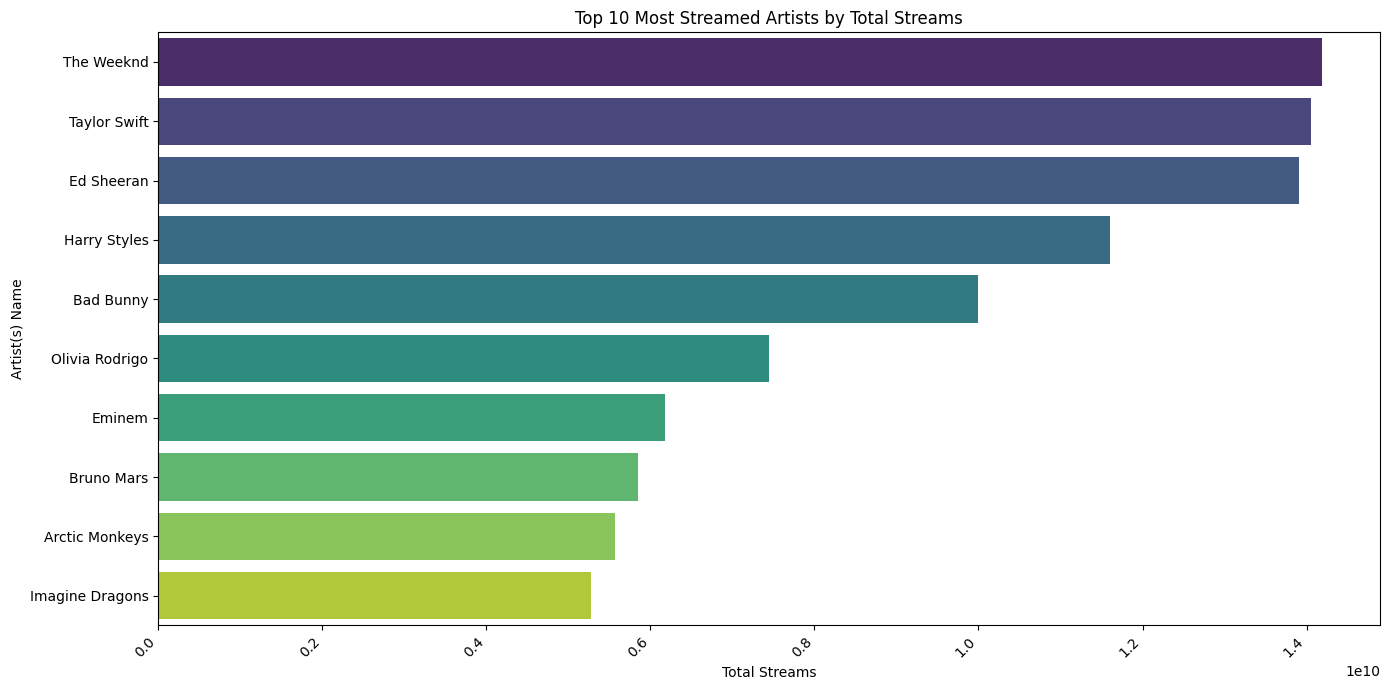

In [ ]:
# Convert the 'artist' Series to a DataFrame for plotting
artist_df = artist.reset_index()
artist_df.columns = ['artist(s)_name', 'streams']

# Create the bar chart
fig = plt.figure(figsize=(14, 7))
sns.barplot(x='streams', y='artist(s)_name', hue='artist(s)_name', data=artist_df, palette='viridis')
plt.title('Top 10 Most Streamed Artists by Total Streams')
plt.xlabel('Total Streams')
plt.ylabel('Artist(s) Name')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()